# <center>Primality Testing with Pseudoprimes</center>

## <center>Jason Chew</center>

## <center>University of California, Santa Cruz</center>

# Abstract

Sometimes it is enough to say that a number is probably prime, rather than being absolutely sure of its primality. We explore pseudoprimes and their implementation in the Miller-Rabin primality test. We highlight Miller-Rabin as an accurate and fast way to detect the primality of numbers with $100$-digits or more. 

# Introduction

With the grin slowly disappearing from my face and my cheeks filling with bright red, I discover what has not been true all along and yet my pride convinced me otherwise: $91 = 13 \times 7$ is not prime. My intuition was the following: "I don't recall seeing $91$ in my $12 \times 12$ multiplication table back in elementary school, so surely it must be prime." As an aspiring mathematical educator, the goal is to develop a deeper intuition, extending beyond mere memorization of factors, for when a number is prime or composite. We seek to arm ourselves with such intuition, because the question of primality of a number becomes nontrivial when the number is big. For instance, the first six digits of $\pi$: $314159$, is prime, and no multiplication flashcard will tell us that. To this end, we consider the pseudoprimes, which exhibit a characteristic common to all prime numbers yet are themselves composite. We ask, rather than if a number is prime or composite, if the number is a pseudoprime. 

We begin with an elementary primality test. 

# $\oint1.$ An Elementary Primality Test

Testing whether a number is prime or not is relatively easy given the number is small. Let $n$ denote the number we wish to test for primality. We start the process by trial dividing $n$ by $2, 3, 4, \ldots$, and so on until we find a factor. Note that since any $n$ has a unique prime factorization, we may also consider trial dividing $n$ starting with the primes $2, 3, 5, \ldots$, etc. If we're lucky, we might find a factor within the lower range of the numbers $2, 3, ... , n - 1$. Otherwise, we may think that trial division of $n$ by all numbers $2, 3, ..., n - 1$ is necessary in order to conclude primality for $n$. It turns out, however, that trial dividing with only the numbers $2, 3, ..., \sqrt{n}$ is enough (Ribenboim, 1996). 

**Proposition 1**. If $n$ is a composite number, then it has a prime factor less than or equal to $\sqrt{n}$.

> *Proof.* Suppose $n$ is a composite number. Then, we may write $n = p\cdot q$ for some prime numbers $p$ and $q$ such that $p \leq q$. Then, we have that 

>$$
\begin{align*}
& p \leq q = \frac{n}{p} \\
& \Rightarrow p \leq \frac{n}{p} \\
& \Rightarrow p^{2} \leq n \\ 
& \Rightarrow p \leq \sqrt{n}. \blacksquare \\
\end{align*}
$$

Let's consider a brief example to illustrate this result. 

**Example 1**. Let $n = 341$. Note that $18^{2} = 324$ and $19^{2} = 361$. So, $\sqrt{341}$ must be between $18$ and $19$. By Proposition 1, if $341$ is in fact a composite number, then it must have a factor less than or equal to $18$. Because $341$ is odd and not a multiple of $5$, the possible prime factors less than $\sqrt{341}$ are $3, 7, 11, 13,$ and $17$.

The existence of a prime factor less than the square root of a number means that the number is not prime. We use this to develop our first primality test. 

In [3]:
import math # We import the math module to make use of the sqrt() and ceil() functions. 

def trial_division(n):
    '''User enters an integer n, return False if n is composite or True if n is prime.'''
    
    if n == 2: # We handle n = 2 right at the beginning.
        return True 
    
    if n % 2 == 0: # If n is even, then n is composite because 2 divides n. 
        return False
    
    for number in range(2, math.ceil(math.sqrt(n)) + 1): # range(2, math.ceil(math.sqrt(n)) + 1) is Python for the 
                                                         # range of numbers between 2, 3, ... , square root of n. 
                                                         # Note that we add 1 because the Python range() function
                                                         # does not include the end argument.  
        if n % number == 0:
            return False # We found a prime factor less than or equal to the square root of n. So, n is composite. 
   
    return True # This means we have tested all numbers from 2 up to the square root of n, 
                # and could not find a factor. So, n is prime. 

In [4]:
trial_division(341) # True means prime; False means composite.

False

In [5]:
trial_division(563)

True

In [6]:
trial_division(41041)

False

Our `trial_division(n)` function is meant to emulate what we do by hand. We've learned, since elementary school, to go through the process of long-dividing a number starting with $2, 3, 5, \ldots,$ etc. If we don't find a nontrivial prime factor, then we can state with confidence&mdash;assuming our arithmetic is correct&mdash;that the number is prime. However, this process of long-division, which possibly exhausts all numbers from $2$ up to $\sqrt{n}$, takes a long time. Even for our `trial_division(n)` function, this process is long. To see this, we can time our `trial_division(n)` function.

In [7]:
import timeit # Import the timeit module. 

# timeit() takes the line of code we wish to time (written as a string) for the first argument,
# a string statement to import the function we time for the second argument, and the number of iterations
# we return a time for as a third argument. 
time1 = timeit.timeit("trial_division(341)", "from __main__ import trial_division", number = 1000000)

print("trial_division(341) took {:.4f} seconds.".format(time1)) # Print the result to the user. 
                                                                # The time (in seconds) will be rounded to four 
                                                                # decimal places. 

trial_division(341) took 0.9079 seconds.


Granted, `trial_division(341)` should have taken less than a second to execute. But what about when we test for larger $n$?

In [8]:
trial_division(14741) # Let n = 14741. 

True

In [9]:
time2 = timeit.timeit("trial_division(14741)", "from __main__ import trial_division", number = 1000000)

print("trial_division(14741) took {:.4f} seconds.".format(time2))

trial_division(14741) took 4.9651 seconds.


The output of `trial_division(14741)` was `True`, meaning that $14741$ passed our `trial_division` primality test. So, $14741$ is prime! One reason why `trial_division(14741)` took much longer than `trial_division(341)` is because of these lines of Python code in our `trial_division(n)` function:

`for factor in range(2, math.ceil(math.sqrt(n)) + 1): 
     if n % number == 0:
         return False 
 return True`
 
For `trial_division(14741)` to return `True` means that the for-loop had to have iterated through all numbers between $2$ and $\sqrt{n}$. Going through this entire list of numbers is time-consuming, for both us as humans and for Python. On the other hand, `trial_division(341)` is a relatively fast execution because&mdash;just like us humans&mdash;once we've found a number that divides $n = 341$, there's no sense in trying out any more numbers. So, Python executes the `return False` line at the instant that a factor is found, because the existence of a factor other than $1$ and the number itself means that the number is composite. 

# $\oint 2.$ Results from Number Theory

Though we can freely use `trial_division(n)` to test for the compositeness or primality of any $n$ we make think of, we will soon find that `trial_division(n)` should not be used if $n$ is large. In this section, we consider a couple results from number theory that will become the foundation for more efficient primality tests.  

In [10]:
trial_division(31113) # Reader may omit execution of the following three cells, or replace with your own number
                      # to test! 

False

In [11]:
trial_division(13331)

True

In [ ]:
trial_division(1111111111111111111) # Note that this cell may take a long time to execute. 

## $2.1:$ Fermat's Little Theorem

Let $x$ and $y$ be integers. We say that $x$ and $y$ are *relatively prime* if their greatest common divisor $gcd(x, y) = 1$. Note that if we fix one of either $x$ or $y$ to be prime, say $y$, then "$gcd(x, y) = 1$" is equivalent to saying that $x$ does not divide $y$ unless $x = 1$ or $x = y$ itself.

**Theorem 1 (Fermat's Little Theorem)**. Let $n$ and $a$ be integers. If $n$ is prime and $gcd(n, a) = 1$, then $a^{n-1} \equiv 1 \text{ (mod $n$)}$.

In [13]:
def fermat_little(n, a): 
    '''User enters a modulus n as the first argument and the base a as the second argument, return the 
       value of the built-in Python function pow(), which accepts base, exponent, and 
       modulus as arguments.'''
    
    if math.gcd(n, a) != 1: # We make use of the gcd() function from the imported math module. 
        return "User must enter a base relatively prime to n."

    return pow(a, n - 1, n) # This is the conclusion of Fermat's Little Theorem. 

In [14]:
fermat_little(5, 2) # This is the result of computing 2 raised to the power (5 - 1)
                    # and then reducing (mod 5)

1

In [15]:
fermat_little(13, 4) # This is the result of computing 4 raised to the power (13 - 1)
                     # and then reducing (mod 13). 

1

In [16]:
fermat_little(25, 2) # This is the result of computing 2 raised to the power (25 - 1) 
                     # and then reducing (mod 25). 

16

In [17]:
fermat_little(91, 5) # This is the result of computing 5 raised to the power (91 - 1)
                     # and then reducing (mod 91).

64

Fermat's Little Theorem says that if we are given a prime number $n$ and its greatest common divisor with some integer $a$ is $1$, then the result of `fermat_little(n, a)` must be $1 \text{ (mod $n$)}$.

From the cells above, $5$ and $13$ are prime numbers that caused `fermat_little(n, a)` to output $1 \text{ (mod $n$)}$, whereas $25$ and $91$ are composite numbers that caused `fermat_little(n, a)` to output a number other than $1 \text{ (mod $n$)}$. This observation, however, does not hold true in general. 

In [18]:
fermat_little(341, 2) # This is the result of computing 2 raised to the power (341 - 1)
                      # and then reducing (mod 341).

1

Note that $341$ is a composite number and $gcd(341, 2) = 1$, yet the output of `fermat_little(341, 2)` is $1 \text{ (mod 341)}$.

In Fermat's Little Theorem, we start with assuming the primality of $n$. However, we are interested in the case of when $n$ is arbitrary, determining if $n$ is prime or composite. To this end, we consider the contrapositive of Fermat's Little Theorem.

**Corollary 1.1 (The Contrapositive of Fermat's Little Theorem)**. Let $gcd(n, a) = 1$ where $1 < a < n$. If $a^{n - 1} \not \equiv 1 \text{ (mod $n$)}$, then $n$ is composite.

For some $a$ relatively prime to $n$ where $1 < a < n$, if the output of `fermat_little(n, a)` is not $1 \text{ (mod $n$)}$, then Corollary 1.1 implies that $n$ is composite. Note that the statement "if $a^{n - 1} \equiv 1 \text{ (mod $n$)}$, then $n$ is composite" is not always true. We may consider any prime $n$ as a counterexample. However, some composite numbers, such as $341$, do satisfy such a statement. We will address this more in $\oint 3$. 

We now have a way to detect the compositeness of $n$ given that we choose a base $a$ satisfying the conditions of Corollary 1.1.

In [19]:
fermat_little(341, 3) # 3 raised to the power 347, reduced (mod 341), is not 1 (mod 341).
                      # So, by Corollary 1.1, n = 341 is composite. 

56

In [20]:
fermat_little(123, 5) # 5 raised to the power 122, reduced (mod 123), is not 1 (mod 123).
                      # So, by Corollary 1.1, n = 123 is composite. 

25

In [21]:
fermat_little(1890297, 3)

'User must enter a base relatively prime to n.'

## $2.2:$ The Roots of One property of primes

Continuing our development of commonly used results in primality testing, we consider the polynomial congruence equation $x^{2} - 1 \equiv 0 \text{ (mod $p$)}$, where $p$ is prime.

Letting $p = 7$, we examine the squares of every element $\text{(mod 7)}$. 

In [22]:
for element in range(0, 7): # for-loop iterates through 0, 1, ... , 6; i.e. the elements (mod 7).
    result = pow(element, 2, 7) # Square every element using Python's built-in function pow(). 
    print("{} squared is congruent to {} (mod 7)".format(element, result))

0 squared is congruent to 0 (mod 7)
1 squared is congruent to 1 (mod 7)
2 squared is congruent to 4 (mod 7)
3 squared is congruent to 2 (mod 7)
4 squared is congruent to 2 (mod 7)
5 squared is congruent to 4 (mod 7)
6 squared is congruent to 1 (mod 7)


Note that there are only three possible nonzero squares $\text{(mod 7)}$, namely $1$, $2$, and $4$. Particularly, only the elements $1$ and $5$ produce a square of $1 \text{ (mod 7)}$.

In [23]:
for element in range(0, 23):
    result = pow(element, 2, 23)
    print("{} squared is congruent to {} (mod 23)".format(element, result))

0 squared is congruent to 0 (mod 23)
1 squared is congruent to 1 (mod 23)
2 squared is congruent to 4 (mod 23)
3 squared is congruent to 9 (mod 23)
4 squared is congruent to 16 (mod 23)
5 squared is congruent to 2 (mod 23)
6 squared is congruent to 13 (mod 23)
7 squared is congruent to 3 (mod 23)
8 squared is congruent to 18 (mod 23)
9 squared is congruent to 12 (mod 23)
10 squared is congruent to 8 (mod 23)
11 squared is congruent to 6 (mod 23)
12 squared is congruent to 6 (mod 23)
13 squared is congruent to 8 (mod 23)
14 squared is congruent to 12 (mod 23)
15 squared is congruent to 18 (mod 23)
16 squared is congruent to 3 (mod 23)
17 squared is congruent to 13 (mod 23)
18 squared is congruent to 2 (mod 23)
19 squared is congruent to 16 (mod 23)
20 squared is congruent to 9 (mod 23)
21 squared is congruent to 4 (mod 23)
22 squared is congruent to 1 (mod 23)


When $p = 23$, the same observation can be made: only the elements $1$ and $22$ produce a square of $1 \text{ (mod 23)}$. In fact, it is always the case that only the elements $1$ and $p - 1$ produce a square of $1 \text{ (mod $p$)}$. Note that the element $p - 1$ amounts to $-1 \text{ (mod $p$)}$. 

**Proposition 2**. Given $x^{2} - 1 \equiv 0 \text{ (mod $p$)}$, the solutions are $x \equiv 1, -1 \text{ (mod $p$)}$. Moreover, the solutions are unique $\text{(mod $p$)}$. 

>*Proof.* Assume $x^{2} - 1 \equiv 0 \text{ (mod $p$)}$. Then, we have that $x^{2} - 1 \equiv (x + 1)(x - 1) \equiv 0 \text{ (mod $p$)}$. So, $x + 1 \equiv 0 \text{ (mod $p$)}$ or $x - 1 \equiv 0 \text{ (mod $p$)}$. Equivalently, $x \equiv -1 \text{ (mod $p$)}$ or $x \equiv 1 \text{ (mod $p$)}$. To show uniqueness, suppose there exists another solution $a \not = 1, -1$ such that $a^{2} - 1 \equiv 0 \text{ (mod $p$)}$. Then, $a^{2} - 1 \equiv (a + 1)(a - 1) \equiv 0 \text{ (mod $p$)}$, implying that $a \equiv -1 \text{ (mod $p$)}$ or $a \equiv 1 \text{ (mod $p$)}$. But, in either case, we have a contradiction with our hypothesis. Hence, the solutions $x \equiv 1, -1 \text{(mod $p$)}$ are unique. $\blacksquare$

The property established in Proposition 2 is commonly referred to as the *Roots of One property* (Weissman, 2017). Alternatively, one can say that $x^{2} - 1 \equiv 0 \text{ (mod $p$)}$ has no nontrivial solutions $\text{(mod $p$)}$, a simple fact that many primality tests will make use of.

# $\oint 3.$ Pseudoprimes

Recall from $\oint 3$ that while Corollary 1.1 will always be true, the statement: "if $a^{n - 1} \equiv 1 \text{ (mod $n$)}$, then $n$ is composite" will only sometimes be satisfied. This latter statement gives rise to the definition of pseudo-primality. 

## $3.1:$ $2$-pseudoprimes

**Definition 1**. If $2^{n - 1} \equiv 1 \text{ (mod $n$)}$ and $n$ is composite, then we call $n$ a *$2$-pseudoprime*. We may read this as "$n$ is a two-pseudoprime" or "$n$ is a pseudoprime to the base $2$."

**Remark 1**. For any prime number $p \not = 2$, $2^{p - 1} \equiv 1 \text{ (mod $p$)}$. 

>*Proof.* Suppose $p \not = 2$ is a prime number and $2^{p - 1} \not \equiv 1 \text{ (mod $p$)}$. Then, by Corollary 1.1, we have that $p$ must be composite, which is a contradiction. Hence, given any odd prime number $p$, $2^{p - 1} \equiv 1 \text{ (mod $p$)}$. $\blacksquare$

The composite number $341$ is a $2$-pseudoprime since $2^{340} \equiv 1 \text{ (mod 341)}$. In fact, $341$ is the smallest $2$-pseudoprime. This means that given any composite number $n$ and fixing the base $a = 2$, the earliest we would expect $2^{n - 1} \equiv 1 \text{ (mod $n$)}$ would be when $n = 341$. One then might consider the question of how many $2$-pseudoprimes there are relative to some upper bound or to the number of primes (Pomerance, Selfridge & Wagstaff, 1980).

| Number of 2-pseudoprimes 	| Number of primes 	| Upper bound Number 	|
|:-------------------------:|:-----------------:|----------------------:|
| 3                        	| 168              	| 1000              	|
| 2,057                    	| 5,761,455        	| 100,000,000       	|
| 19,685                   	| 882,206,716      	| 20,000,000,000    	|

By observing the table, we see that there are many more primes than $2$-pseudoprimes. In fact, if we randomly choose a number $n < 2 \times 10^{10}$ and verify that $2^{n - 1} \equiv 1 \text{ (mod $n$)}$, then citing Remark 1, $n$ is either an odd prime number or a $2$-pseudoprime. Based on the counts given in the table, the probability of $n$ being a $2$-pseudoprime is 0.000098425%, or in terms of the complement: $n$ has a 99.999901575% chance of not being a $2$-pseudoprime; that is, this is the probability of $n$ being a prime number! The number theorist Henri Cohen jokingly dubbed $2$-pseudoprimes as "industrial grade primes", because given that $n < 2\times 10^{10}$ and $n$ satisifes $2^{n - 1} \equiv 1 \text{ (mod $n$)}$, we have a very low chance that $n$ will be composite (Childs, 1995, p. 171).

## $3.2:$ $a$-pseudoprimes

To introduce the next definition for pseudoprimes, let's first consider the composite square numbers: $16$ and $25$. We will use `fermat_little(n, a)` from $\oint 2$ using the base $a = 3$.

In [26]:
fermat_little(16, 3) # This is the result of computing 3 raised to the power 15,
                     # and then reducing (mod 16). 

11

In [27]:
fermat_little(25, 3) # This is the result of computing 3 raised to the power 24,
                     # and then reducing (mod 25). 

6

Our intuition for the fact that $16$ and $25$ are composite numbers may just be due to how familiar we are with their prime factorizations. Corollary 1.1 confirms this intuition and gives us an alternative test for compositeness. In contrast to considering a prime factor of a number, `fermat_little(n, a)` uses an important input parameter to detect the compositeness of a number: the base $a$. We addressed the case when $a = 2$ in $3.1$.

In [37]:
def fermat_little_v2(n):
    '''User inputs an integer n, function prints the conclusion of Fermat's Little Theorem for bases a in 
       the range a = 1, 2, ... , n - 1.'''

    # for-loop will iterate over all bases relatively prime to n, in the range 2, ... , n - 1. 
    for a in [base for base in range(2, n) if math.gcd(n, base) == 1]:
                                                                        
        result = fermat_little(n, a)
        
        # Note that we adopt the ^ to denote raising a base to a power. 
        print("{0}^{1} is congruent to {2} (mod {3})".format(a, n - 1, result, n))

In [38]:
fermat_little_v2(16)

3^15 is congruent to 11 (mod 16)
5^15 is congruent to 13 (mod 16)
7^15 is congruent to 7 (mod 16)
9^15 is congruent to 9 (mod 16)
11^15 is congruent to 3 (mod 16)
13^15 is congruent to 5 (mod 16)
15^15 is congruent to 15 (mod 16)


In [39]:
fermat_little_v2(25)

2^24 is congruent to 16 (mod 25)
3^24 is congruent to 6 (mod 25)
4^24 is congruent to 6 (mod 25)
6^24 is congruent to 21 (mod 25)
7^24 is congruent to 1 (mod 25)
8^24 is congruent to 21 (mod 25)
9^24 is congruent to 11 (mod 25)
11^24 is congruent to 16 (mod 25)
12^24 is congruent to 11 (mod 25)
13^24 is congruent to 11 (mod 25)
14^24 is congruent to 16 (mod 25)
16^24 is congruent to 11 (mod 25)
17^24 is congruent to 21 (mod 25)
18^24 is congruent to 1 (mod 25)
19^24 is congruent to 21 (mod 25)
21^24 is congruent to 6 (mod 25)
22^24 is congruent to 6 (mod 25)
23^24 is congruent to 16 (mod 25)
24^24 is congruent to 1 (mod 25)


Inspecting our output, we can make the following deductions:

* When $n = 16$, for all $a$ such that $gcd(16, a) = 1$ and $1 < a < 16$, `fermat_little(16, a)` will not output $1 \text{ (mod 16)}$.


* When $n = 25$, for some $a$ such that $gcd(25, a) = 1$ and $1 < a < 25$,  `fermat_little(25, a)` will not output $1 \text{ (mod 25)}$. While when $a = 7, 18,$ or $24$, we have that

$$
\begin{align*}
7^{24} &\equiv 1 \text{ (mod 25)} \\
18^{24} &\equiv 1 \text{ (mod 25)} \\
24^{24} &\equiv 1 \text{ (mod 25)}. \\
\end{align*}
$$

**Definition 3**. Let $gcd(n, a) = 1$ where $1 < a < n$. If $a^{n - 1} \equiv 1 \text{ (mod $n$)}$ and $n$ is composite, then we call $n$ an $a$-*pseudoprime*.

We say that $25$ is a $7$-pseudoprime, $18$-pseudoprime, or $24$-pseudoprime, while $16$ is not a pseudoprime to any base $a$. Yet, $25$ and $16$ are both composite numbers. Since we can find an $a$ such that $a^{24} \equiv 1 \text{ (mod 25)}$, we conventionally say that $25$ is *probably prime*, whereas $16$ has no way of being considered prime at all. Of course, we know that $25$ is certainly not prime. In general, if we can find an $a$ such that $a^{n - 1} \equiv 1 \text{ (mod $n$)}$, then we might be able to ascertain $n$'s primality since, by Fermat's Little Theorem, for any prime $n$ there exists an $a$ such that $a^{n - 1} \equiv 1 \text{ (mod $n$)}$. More explicitly: if $n$ is prime, then for all $a$ where $1 \leq a < n$, $a^{n - 1} \equiv 1 \text{ (mod $n$)}$. 

In [40]:
fermat_little_v2(13) # Consider when n = 13, a prime. Note that the trivial case of when a = 1
                     # is not printed by fermat_little_v2(n). 

2^12 is congruent to 1 (mod 13)
3^12 is congruent to 1 (mod 13)
4^12 is congruent to 1 (mod 13)
5^12 is congruent to 1 (mod 13)
6^12 is congruent to 1 (mod 13)
7^12 is congruent to 1 (mod 13)
8^12 is congruent to 1 (mod 13)
9^12 is congruent to 1 (mod 13)
10^12 is congruent to 1 (mod 13)
11^12 is congruent to 1 (mod 13)
12^12 is congruent to 1 (mod 13)


In [41]:
fermat_little_v2(17) # Consider when n = 17, a prime. 

2^16 is congruent to 1 (mod 17)
3^16 is congruent to 1 (mod 17)
4^16 is congruent to 1 (mod 17)
5^16 is congruent to 1 (mod 17)
6^16 is congruent to 1 (mod 17)
7^16 is congruent to 1 (mod 17)
8^16 is congruent to 1 (mod 17)
9^16 is congruent to 1 (mod 17)
10^16 is congruent to 1 (mod 17)
11^16 is congruent to 1 (mod 17)
12^16 is congruent to 1 (mod 17)
13^16 is congruent to 1 (mod 17)
14^16 is congruent to 1 (mod 17)
15^16 is congruent to 1 (mod 17)
16^16 is congruent to 1 (mod 17)


A way to confirm whether $n$ is prime or not is to check if for all $a$ in $1 < a < n$, we will have that $a^{n - 1} \equiv 1 \text{ (mod $n$)}$. However, this approach, given that $n$ is a large number, is inefficient in both time and memory&mdash;for Python, and certainly for the human! In essence, this approach requires computing $a^{n - 1}$ a total of $n - 2$ many times and reducing (mod $n$) each time.

In [42]:
def test_function(n):
    '''A test function that will compute a^{n - 1} a total of n - 2 many times and reduce (mod n) each time. 
       Note that function has no return statement, nor will any output be displayed to the user.'''
    
    for a in range(2, n): # The variable a iterates over the range 2, ... , n - 1. 
        raise_power = (a ** (n - 1)) # Compute a^{n - 1}. 
        reduce = raise_power % n # Reduce a^{n - 1} (mod n). 

In [43]:
test_function(929) # n = 929 is a Palindromic prime. 

In [44]:
test_function_929_time = timeit.timeit("test_function(929)", "from __main__ import test_function", number = 4)

print("test_function(929) took {:.4f} seconds over 4 iterations.".format(test_function_929_time))

test_function(929) took 0.0648 seconds over 4 iterations.


In [45]:
test_function(8191) # n = 8191 is a Mersenne prime. 

In [46]:
test_function_8191_time = timeit.timeit("test_function(8191)", "from __main__ import test_function", number = 4)

print("test_function(8191) took {:.4f} seconds over 4 iterations.".format(test_function_8191_time))

test_function(8191) took 24.7782 seconds over 4 iterations.


We should have observed a wide time difference between `test_function(929)` and `test_function(8191)`. Note that we purposely chose the number of iterations to be $4$. One may increase the number in the line `number = 4` and acquire a more accurate sense of how long each computation takes, but at the expense of a long running cell. Nonetheless, we can still observe the contrast of how long it takes Python to go through successive computations of $a^{n - 1} \text{(mod $n$)}$ for $3$, $4$, and $5$-digit prime numbers. 

In [47]:
test_function(10079) # n = 10079 is a Primeval prime. 

In [48]:
test_function_10079_time = timeit.timeit("test_function(10079)", "from __main__ import test_function", number = 4)

print("test_function(10079) took {:.4f} seconds over 4 iterations.".format(test_function_10079_time))

test_function(10079) took 43.7971 seconds over 4 iterations.


We can conclude that Python takes a long time to confirm the primality of $n$, given that our implementation is to compute $a^{n - 1} \text{ (mod $n$)}$ for a total of $n - 2$ many times. Though in $\oint 1$ we observed the long execution time of `trial_division(14741)`, for $n = 929, 8191, 10079$, `trial_division(n)` is faster than the implementation in `test_function(n)`.

In [49]:
trial_division(929)

True

In [50]:
trial_division(8191)

True

In [51]:
trial_division(10079)

True

In [52]:
trial_division_929_time = timeit.timeit("trial_division(929)", "from __main__ import trial_division", number = 1000000)
trial_division_8191_time = timeit.timeit("trial_division(8191)", "from __main__ import trial_division", number = 1000000)
trial_division_10079_time = timeit.timeit("trial_division(10079)", "from __main__ import trial_division", number = 1000000)

print("trial_division(929) took {:.4f} seconds.".format(trial_division_929_time))
print("trial_division(8191) took {:.4f} seconds.".format(trial_division_8191_time))
print("trial_division(10079) took {:.4f} seconds.".format(trial_division_10079_time))

trial_division(929) took 1.6367 seconds.
trial_division(8191) took 3.7755 seconds.
trial_division(10079) took 4.1739 seconds.


## $3.3:$ A new, promising primality test

Rather than go through successive computations of $a^{n - 1} \text{(mod $n$)}$, we may consider testing the primality of $n$ simply for a few values of $a$. If we find that $n$ is not an $a$-pseudoprime (such as $16$ for any base $a$), then it is certainly not prime. In other words, if at least one of our test bases $a$ satisfy the conditions of Corollary 1.1, then $n$ is composite. On the other hand, if all of our test bases $a$ cause the output of `fermat_little(n, a)` to be $1 \text{(mod $n$)}$, then the most we can say is that $n$ is probably prime.

In [53]:
import random # We make use of the random module from Python's standard library. 

def trial_a_pseudoprime(n):
    '''User enters an integer n, return False if n is composite or True if n is probably prime.'''
    
    bases = [] # We start with an empty list of bases. 
    
    num = 50 # We test with 50 randomly chosen bases. 
    
    while True:
        j = random.randrange(2, n) # We choose random bases in the range 2, 3, ... , n - 1.
        if math.gcd(n, j) == 1: # Check if base j is relatively prime to n. 
            bases.append(j) # If so, append j to the list bases. 
        else: # If not, continue to the next iteration until we find a j relatively prime to n. 
            continue
            
        if len(bases) == num: # Once we have 50 bases relatively prime to n, break from the while-loop. 
            break
    
    for a in bases:
        result = fermat_little(n, a) # Compute, for each randomly chosen base a, fermat_little(n, a). 
        if result != 1: # If we find that fermat_little(n, a) is not 1, then by Corollary 1.1, 
                        # n must be composite. 

            return False # return False; i.e. n is composite. 
        
    return True # If we return True, then among the 50 randomly chosen bases a, fermat_little(n, a)
                # was found to be 1 (mod n). Hence, n is probably prime. 

In [55]:
trial_a_pseudoprime(679) # True means probably prime; False means composite. 

False

In [56]:
trial_a_pseudoprime(331) 

True

Given the randomness of our chosen bases, we want to check the accuracy of `trial_a_pseudoprime(n)`. We do an experiment in the following cells by executing `trial_a_pseudoprime(n)` 10,000 times for a given $n$, keeping track of how many times `trial_a_pseudoprime(n)` returns `True` or `False` and plotting the results in a bar graph. 

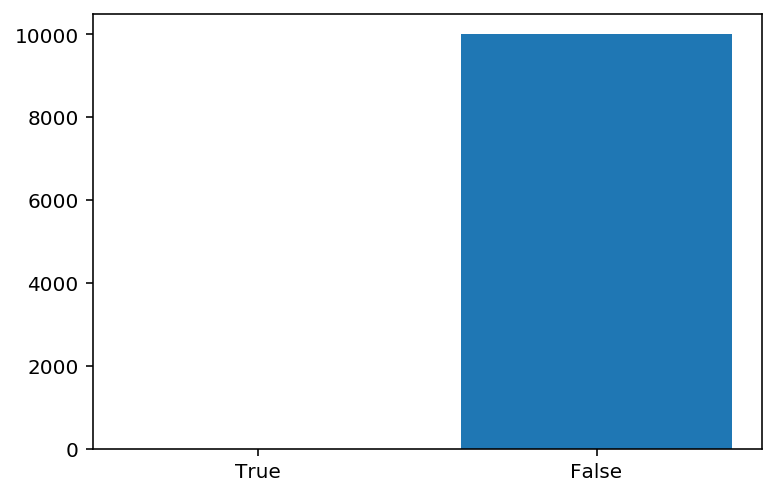

This is the experiment when n = 679.


In [57]:
import matplotlib.pyplot as plt # We make use of the plotting library. 

%config InlineBackend.figure_format = 'retina' # Gives us a nice looking graph. 

d1 = {"True": 0, "False": 0} # The dictionary d1 will keep track of how many times trial_a_pseudoprime(679)
                            # returns True or False; i.e. how many times our new primality test says 679
                            # is probably prime or composite. 

for i1 in range(10000): # We are effectively executing trial_a_pseudoprime(679) 10,000 times, for accuracy. 
    
    if trial_a_pseudoprime(679):
        d1["True"] += 1 # trial_a_pseudoprime(679) returned True. 
    else:
        d1["False"] += 1 # trial_a_pseudoprime(679) returned False. 

plt.bar(d1.keys(), d1.values())  
plt.show() # Display to the user a bar graph of the data.

print("This is the experiment when n = 679.")

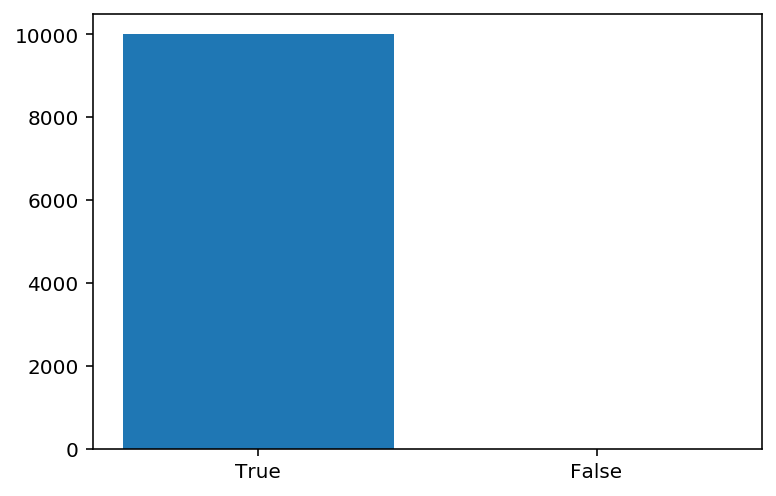

This is the experiment when n = 331.


In [58]:
%config InlineBackend.figure_format = 'retina'

d2 = {"True": 0, "False": 0} # The dictionary d2 will keep track of how many times trial_a_pseudoprime(331)
                            # returns True or False; i.e. how many times our new primality test says 331
                            # is probably prime or composite. 

for i2 in range(10000): # We are effectively executing trial_a_pseudoprime(331) 10,000 times, for accuracy. 
    
    if trial_a_pseudoprime(331):
        d2["True"] += 1 # trial_a_pseudoprime(331) returned True. 
    else:
        d2["False"] += 1 # trial_a_pseudoprime(331) returned False. 

plt.bar(d2.keys(), d2.values())  
plt.show() # Display to the user a bar graph of the data.

print("This is the experiment when n = 331.")

Based on the experiments above, we are confident to say that $679$ is composite, while $331$ is probably prime.

In [59]:
trial_division(679)

False

In [60]:
trial_division(331) # From trial_division(n), True means (in fact) prime. 

True

Next, we do the experiment with $561$ and $1729$, both composite numbers.

In [61]:
trial_division(561)

False

In [62]:
trial_division(1729)

False

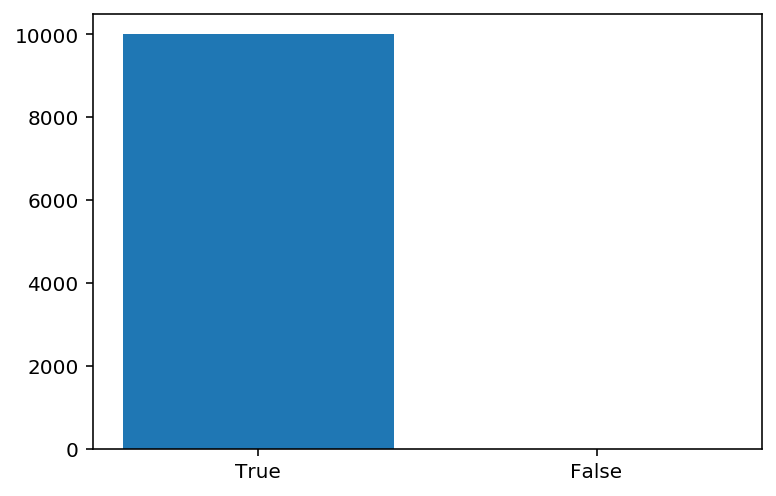

This is the experiment when n = 561.


In [63]:
%config InlineBackend.figure_format = 'retina' # Gives us a nice looking graph. 

d3 = {"True": 0, "False": 0} # The dictionary d3 will keep track of how many times trial_a_pseudoprime(561)
                            # returns True or False; i.e. how many times our new primality test says 561
                            # is probably prime or composite. 

for i3 in range(10000): # We are effectively executing trial_a_pseudoprime(561) 10,000 times, for accuracy. 
    
    if trial_a_pseudoprime(561):
        d3["True"] += 1 # trial_a_pseudoprime(561) returned True. 
    else:
        d3["False"] += 1 # trial_a_pseudoprime(561) returned False. 

plt.bar(d3.keys(), d3.values())  
plt.show() # Display to the user a bar graph of the data.

print("This is the experiment when n = 561.")

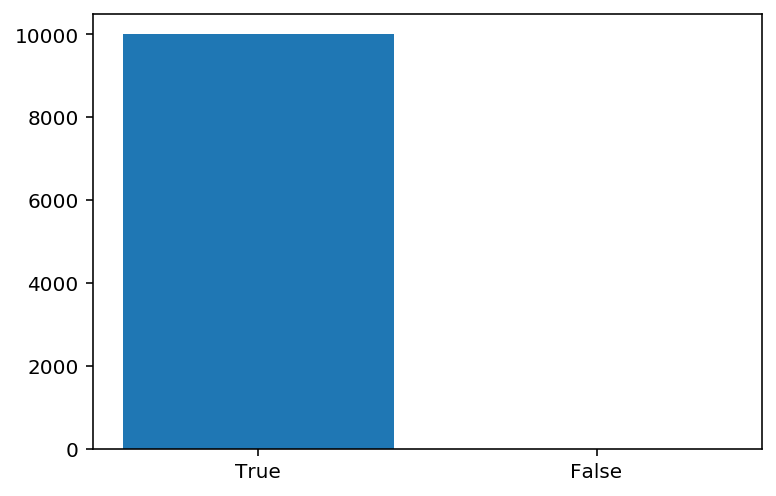

This is the experiment when n = 1729.


In [64]:
%config InlineBackend.figure_format = 'retina'

d4 = {"True": 0, "False": 0} # The dictionary d4 will keep track of how many times trial_a_pseudoprime(1729)
                            # returns True or False; i.e. how many times our new primality test says 1729
                            # is probably prime or composite. 

for i4 in range(10000): # We are effectively executing trial_a_pseudoprime(1729) 10,000 times, for accuracy. 
    
    if trial_a_pseudoprime(1729):
        d4["True"] += 1 # trial_a_pseudoprime(1729) returned True. 
    else:
        d4["False"] += 1 # trial_a_pseudoprime(1729) returned False. 

plt.bar(d4.keys(), d4.values())  
plt.show() # Display to the user a bar graph of the data.

print("This is the experiment when n = 1729.")

We have that `trial_a_pseudoprime(561)` and `trial_a_pseudoprime(1729)` always report that $561$ and $1729$ are probably prime, which should not be the case. 

**Definition 4**. If $n$ is composite and an $a$-pseudoprime for all $a$ relatively prime to $n$, then $n$ is called a *Carmichael number*. 

$561 = 3 \times 11 \times 17$ and $1729 = 7 \times 13 \times 19$ are Carmichael numbers; in fact, they are two of only seven Carmichaels to exist under 10,000 (see table below). Though their existence is rare, any Carmichael number will cause `trial_a_pseudoprime(n)` to return a misdiagnosis of probable primality, which is not what we want an accurate primality test to do. 

**Remark 2**. For a Carmichael number $n$, $a^{n - 1} \equiv 1 \text{ (mod $n$)}$ if and only if $gcd(n, a) = 1$. Equivalently, for a Carmichael number $n$, the only time that we observe $a^{n - 1} \not \equiv 1 \text{ (mod $n$)}$ is precisely when $a$ divides $n$. So, for $n = 561$, $3^{560} \not \equiv 1 \text{ (mod 561)}$, and similarly for the factors $11$ and $17$. 

We end this section by providing a table with the number of Carmichael numbers, $2$-pseudoprimes, and primes, relative to some upper bound (Pomerance, Selfridge & Wagstaff, 1980). 

| Number of Carmichael numbers 	| Number of 2-pseudoprimes 	| Number of primes 	| Upper bound Number 	|
|:-----------------------------:|:-------------------------:|:-----------------:|----------------------:|
| 1                            	| 3                        	| 168              	| 1,000             	|
| 7                            	| 22                       	| 1,229            	| 10,000            	|
| 16                           	| 78                       	| 9,592            	| 100,000           	|
| 43                           	| 245                      	| 78,498           	| 1,000,000         	|
| 105                          	| 750                      	| 664,579          	| 10,000,000        	|
| 255                          	| 2,057                    	| 5,761,455        	| 100,000,000       	|
| 646                          	| 5,597                    	| 50,847,534       	| 1,000,000,000     	|
| 1,547                        	| 14,884                   	| 455,052,511      	| 10,000,000,000    	|
| 2,163                        	| 21,853                   	| < 4,118,054,813  	| 25,000,000,000    	|

# $\oint 4.$ The Miller-Rabin Primality Test

Making use of large prime numbers is at the heart of the RSA Cryptosystem, whose purpose is to encrypt the personal and sensitive data of billions of people all over the world. The RSA Cryptosystem finds two large prime numbers and designates one of the two as the enciphering key, called the *public-key*, and the other as the deciphering-key, called the *private-key*. The product of these two large prime numbers is a large composite number, which is made known to the public. The private-key is not known publicly, but only to the sender and receiver of the encrypted message. In essence, being able to decipher an encrypted message amounts to being able to factor the large composite number into its two prime factors, thus obtaining the private-key. The security of RSA encryption relies on the general fact that, at present, factoring a large composite number into its prime factors is difficult, even for the fastest super-computers of the world (Clawson, 1996). 

We want a primality test to confirm the primality of a number quickly and accurately. The encryption system of RSA cannot afford to use a large number as a public or private-key without being sure of its primality. To do so jeopardizes the secure connections of worldwide institutions such as NATO, Boeing, and CitiBank&mdash;not to mention the online communications of billions of people around the world. We have already seen in $\oint 3$ how Carmichael numbers are misdiagnosed as probable primes by `trial_a_pseudoprime(n)`. We start this section by highlighting a deficiency behind `trial_division(n)`, and end with one of the most commonly used primality tests of today: the Miller-Rabin primality test. 

## $4.1:$ Deficiency of elementary primality test

Recall from $\oint 1$ how long it took Python to execute `trial_division(14741)`. We can observe that given just a 6-digit prime, `trial_division(n)` executes hopelessly slower. 

In [65]:
trial_division(181081) # n = 181081 is a Dihedral prime. 

True

In [66]:
trial_division_181081_time = timeit.timeit("trial_division(181081)", "from __main__ import trial_division", number = 1000000)

print("trial_division(181081) took {:.4f} seconds.".format(trial_division_181081_time))

trial_division(181081) took 19.6556 seconds.


In [ ]:
# We take the difference between the execution times of trial_division(181081) and trial_division(14741).
# Reader may omit execution of this cell. 

time_value1 = timeit.timeit("trial_division(181081)", "from __main__ import trial_division", number = 1000000)
time_value2 = timeit.timeit("trial_division(14741)", "from __main__ import trial_division", number = 1000000)

print("Time-difference between trial_division(181081) and trial_division(14741): {:.4f} seconds.".format(time_value1 - time_value2))

As we test for higher digit primes, `trial_division(n)` executes slower and slower. In the following cell, we plot `trial_division(n)` execution times on the $y$-axis for $x$-digit prime numbers on the $x$-axis.

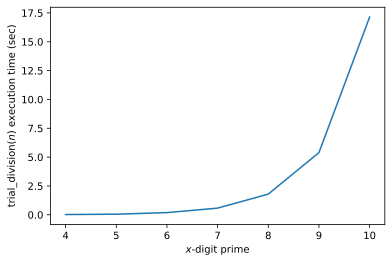

Plotted data points: (4, 0.0239), (5, 0.0545), (6, 0.1926), (7, 0.5814), (8, 1.7975), (9, 5.3955), (10, 17.1371).

In [68]:
%config InlineBackend.figure_format = 'svg' # Makes our plot look bigger and better. 

trial_division_times = [] # An empty list that we will append trial_division(n) execution times to. 

primes = [1741, 14741, 181081, 1230547, 11131741, 100000007, 1012802701] 
# An assortment of 4, 5, ... , 10-digit primes taken from Wikipedia and Prime Curios! from University of Tenn. 

# for-loop iterates through the assortment of primes, time trial_division(p) at the 
# rate of 10,000 iterations, appends each time value to trial_division_times. 
for p in primes:
    t = timeit.timeit("trial_division({})".format(p), "from __main__ import trial_division", number = 10000)
    trial_division_times.append(t)
    
x = [len(str(num)) for num in primes] # Count the digits of each number in the primes list. 
 
y = [round(time_element, 4) for time_element in trial_division_times] # Round each time execution to 4 decimal places. 

plt.figure()
plt.plot(x, y)
plt.xlabel('$x$-digit prime')
plt.ylabel('trial_division($n$) execution time (sec)')
plt.show()

data_points = {} # Dictionary to keep track of the (x, y) data points. 

for i in range(len(x)): # for-loop appends data point as a key-value pair in the data_points dictionary. 
    data_points[x[i]] = y[i]
    
print("Plotted data points: ", end = '') # Print the data points to the user in a readable format. 
    
counter = 0
    
for key, value in data_points.items():
    
    if counter == (len(x) - 1):
        print("({}, {})".format(key, value), end = '.')
        break
    
    print("({}, {})".format(key, value), end = ', ') 
    
    counter += 1

It appears that the relationship between successively higher digit prime numbers and the execution time of `trial_division(n)` for such primes is exponential! This is really not good considering RSA typically makes use of prime numbers falling within the range of $50$ and $1024$-digits. Time-efficiency is not what `trial_division(n)` is good for. 

## $4.2:$ Strong $a$-pseudoprimes

We want an accurate, time-efficient, and overall reliable test to confirm the primality or compositeness of $n$. The issues we encountered were Carmichael numbers and the inability to quickly ascertain $n$'s primality. Both issues will be addressed by implementing the following definition (Childs, 1995). 

**Definition 5**. Let $n$ be an odd composite integer such that $n - 1 = 2^{d}r$, where $r$ is odd and $d > 0$, and choose an $a$ such that $gcd(n, a) = 1$ where $1 < a < n$. If $a^{r} \equiv 1 \text{ (mod $n$)}$ or there exists a $k < d$ so that $a^{2^{k}r} \equiv -1 \text{ (mod $n$)}$, then we call $n$ a *strong $a$-pseudoprime*.

**Example 2**. Let $n = 91$ and $a = 12$. Note that $gcd(91, 12) = 1$. We have that $90 = 2 \cdot 45$. Then, $12^{45} \equiv 90 \equiv -1 \text{ (mod 91)}$. So, $91$ is a strong $12$-pseudoprime. 

For $n$ to be a strong $a$-pseudoprime implies that $n$ is an $a$-pseudoprime, because if $a^{r} \equiv 1 \text{ (mod $n$)}$, then we have that

$$
\begin{align*}
a^{r} \equiv 1 \text{ (mod $n$)} & \Rightarrow (a^{r})^{2^{d}} \equiv (1)^{2^{d}} \text{ (mod $n$)} \\ 
& \Rightarrow a^{2^{d}r} \equiv 1 \text{ (mod $n$)} \\
& \Rightarrow a^{n - 1} \equiv 1 \text{ (mod $n$)}. \\
\end{align*} 
$$

In the case of when $a^{2^{k}r} \equiv -1 \text{ (mod $n$)}$ for some $k < d$, we can repeatedly square both sides of the congruence until we have that $a^{2^{d}r} \equiv 1 \text{ (mod $n$)}$, implying that $a^{n - 1} \equiv 1 \text{ (mod $n$)}$, which means $n$ is an $a$-pseudoprime. Also, if $a^{2^{k}r} \equiv -1 \text{ (mod $n$)}$, then taking the square of both sides gives $(a^{2^{k}r})^{2} \equiv (-1)^{2} \equiv 1 \text{ (mod $n$)}$. In other words, $a^{2^{k}r} \equiv -1 \text{ (mod $n$)}$ is a solution to the polynomial congruence equation $x^{2} - 1 \equiv 0 \text{ (mod $n$)}$, a property that we observed must be true for when $n$ is prime (see $\oint 2$). On the other hand, if from our choice of the base $a$ we find that $(a^{2^{k}r})^{2} \equiv 1 \text{ (mod $n$)}$, but $a^{2^{k}r} \not \equiv -1 \text{ (mod $n$)}$, then we violate the Roots of One property of primes; hence, $n$ must be composite!

Constructing a primality test using strong $a$-pseudoprimes will retain the advantages of `trial_a_pseudoprime(n)`, in the sense that any prime $n$ will pass such a test for any choice of the base $a$. However, unlike `trial_a_pseudoprime(n)` and its probable prime diagnosis for Carmichael numbers, the benefit of a strong $a$-pseudoprime test is that most composite numbers will likely fail for any relatively prime base $a$. Furthermore, by checking if $a^{r} \equiv 1 \text{ (mod $n$)}$ or $a^{r} \not \equiv 1 \text{ (mod $n$)}$, we are effectively determining if the conditions of Corollary 1.1 are satisfied. The upshot is that many composite numbers will satisfy the implication: $a^{r} \not \equiv 1 \text{ (mod $n$)} \Rightarrow a^{n - 1} \not \equiv 1 \text{ (mod $n$)}$, and that though Carmichael numbers sneakily evade this implication, they will violate the Roots of One property. 

**Remark 3**. If we were to take away the condition of $n$ being composite in our definitions for $2$-pseudoprimes, $a$-pseudoprimes, or strong $a$-pseudoprimes, then we simply say that such an $n$ meeting the definitions is *probably prime* or $n$ is called a *probable prime*. 

In [69]:
def strong_a_pseudoprime_test(n, a):
    '''User enters an odd integer n and an integer a such that gcd(n, a) = 1, return False if 
       n is composite or True if n is probably prime.'''

    if math.gcd(n, a) != 1 or a == 1:
        return "User entered an invalid base."

    if n % 2 == 0:
        return "User must enter an odd integer n."

    num = n - 1 # If n is odd, then num is even. 
                # Note that num is congruent to -1 (mod n). 

    sequence = [] # We start with any empty list called sequence, to which we will append 
                  # a^{odd_factor}, then the square of a^{odd_factor}, then the square of that, etc. 

    exponent = num # Assign the variable exponent with the value n - 1. 

    while True: # The while-loop will continuously execute until break statement is reached. 
        
        element = pow(a, exponent, n) # Assign the variable element with the value a^{n - 1} (mod n);
                                      # i.e. fermat_little(n, a). 
            
        sequence.append(element) # Append such an element to the sequence list. 

        if exponent % 2 == 1: # Here we check if our exponent is odd, in which case we want to end the while-loop. 
            break

        exponent //= 2 # Otherwise, cut the exponent (which starts out as an even number) in half 
                       # to attain the next square element of sequence. 

    # Note that the order of elements in sequence are such that:
    # sequence = [a^{n - 1}, a^{(n - 1)/2}, ... , a^{r}]. The elements are achieved by repeatedly squaring 
    # the element a^{r}, until we have a^{n - 1}. 
    
    if sequence[len(sequence) - 1] == 1 or num in sequence:
        
        # Using list indexing, sequence[len(sequence - 1)] is exactly the element a^{r}, where r is odd. 
        # If a^{r} is congruent to 1 (mod n), then n is probably prime. 
        
        # The other condition is to check if -1 is among the square elements of sequence. If so, then
        # n is probably prime. 
        
        return True
    
    else:
        
        return False # If both conditions were not satisfied, then n is composite. 

To get a feel for `strong_a_pseudoprime_test(n, a)`, we will execute the cells below. Then, we consider each execution in detail, aiming to bring out the intuition behind `strong_a_pseudoprime_test(n, a)`. 

In [70]:
strong_a_pseudoprime_test(97, 3)

True

In [71]:
strong_a_pseudoprime_test(561, 5)

False

In [72]:
strong_a_pseudoprime_test(25, 11)

False

**Example 3**. For `strong_a_pseudoprime_test(97, 3)`, we let $n = 97$ and $a = 3$. Note that $gcd(97, 3) = 1$. Our goal is to determine whether $97$ is composite or probably prime. To do this, we invoke the definition of a strong $a$-pseudoprime by seeking to write $96$ as the product of a power of $2$ with some odd integer; in other words, we need to find a positive integer $d$ and an odd integer $r$ such that $96 = 2^{d}r$. We can consider repeatedly dividing by $2$ obtaining $2^{d - i}r$ for $i = 1, 2, ... j$, until we find that $2^{d - j}r$ is an odd integer. That is, 

$$
\begin{align*}
& \space 2^{d}r = 96 \\
\Rightarrow & \space 2^{d - 1}r = 48 \\
\Rightarrow & \space 2^{d - 2}r = 24 \\
\Rightarrow & \space 2^{d - 3}r = 12 \\
\Rightarrow & \space 2^{d - 4}r = 6 \\
\Rightarrow & \space 2^{d - 5}r = 3. \\
\end{align*}
$$

From the last line, take $d = 5$, then we have that $r = 3$. To further investigate whether $n$ meets the definition of a strong $a$-pseudoprime, we compute the base $a = 3$ raised to each of the numbers we found above and reduce (mod $97$). We will have the following sequence of numbers:

$$
\begin{align*}
3^{3} \equiv 27, \space 3^{6} \equiv 50, \space 3^{12} \equiv 75, \space 3^{24} \equiv 96, \space 3^{48} \equiv 1, \space 3^{96} \equiv 1 \text{ (mod 97)}. \\ 
\end{align*}
$$

`strong_a_pseudoprime_test(97, 3)` returns `True` because $96 \equiv -1 \text{ (mod 97)}$ was found among this sequence of numbers. Consequently, $3^{48} \equiv \big(3^{24}\big)^{2} \equiv (96)^{2} \equiv (-1)^{2} \equiv 1 \text{ (mod 97)}$. So, $97$ satisfies the Roots of One property of primes. Hence, $97$ is probably prime.  

**Example 4**. For `strong_a_pseudoprime_test(561, 5)`, we test the Carmichael number $561$. Note the fact that $5^{560} \equiv 1 \text{ (mod 561)}$ does not tell us much. This does not satisfy the conditions of Corollary 1.1, nor can we justify that $561$ is a $5$-pseudoprime since we do not yet have the knowledge that $561$ is composite. So, all we can say is that $561$ has a chance of being prime. Invoking the definition of strong $a$-pseudoprimes, we have that 

$$
\begin{align*}
5^{35} \equiv 23, \space 5^{70} \equiv 529, \space 5^{140} \equiv 463, \space 5^{280} \equiv 67, \space 5^{560} \equiv 1 \text{ (mod 561)}. \\ 
\end{align*}
$$

Since $5^{35} \equiv 23 \not \equiv 1 \text{ (mod 561)}$, the conclusion for $561$ to be considered a probable prime hinges on whether there exists a $k < 4$ ($4$ is the number of times we took successive squares) such that $5^{35 \cdot 2^{k}} \equiv -1 \text{ (mod 561)}$. However, examining the sequence above, no such $k$ exists. Hence, $561$ is not probably prime, necessarily implying that $561$ is composite. 

Because $561$ is a Carmichael number, for most $a$ in the range $1 \leq a < 561$, we will find that $a^{560} \equiv 1 \text{ (mod 561)}$. In fact, the only time $a^{560} \not \equiv 1 \text{ (mod 561)}$ is when $a = 1, 3, 11, 17, 33, 51,$ and $187$, which are exactly the factors of $561$ (see **Remark 2**). In other words, we will likely find an $a$ so that $a^{560} \equiv \big(a^{280}\big)^{2} \equiv 1 \text{ (mod 561)}$, and we advantageoulsy do not need to choose a large $a$ (such as $a = 560$) in order to observe this fact for $561$. In effect, we are showing that $561$ violates the Roots of One property of primes. From the above computation, we have that 

$$
\begin{align*}
5^{560} \equiv \big(5^{280}\big)^{2} \equiv (67)^{2} \equiv 1 \text{ (mod 561)}. \\ 
\end{align*}
$$ 

This means $67$ is a solution to $x^{2} - 1 \equiv 0 \text{ (mod 561)}$, which cannot be true if $561$ is to be considered probably prime. 

**Example 5**. The strong $a$-pseudoprime definition applied to $n = 25$ and $a = 11$ will give the following:

$$
\begin{align*}
11^{3} \equiv 6, \space 11^{6} \equiv 11, 11^{12} \equiv 21, 11^{24} \equiv 16 \text{ (mod 25)}. \\ 
\end{align*}
$$

We have that the first term $11^{3} \equiv 6 \not \equiv 1 \text{ (mod 25)}$, and any successive square term from the above sequence is not congruent to $-1 \text{ (mod 25)}$. So, $25$ is indeed composite. Recall from $\oint 3$ how we observed that the conditions of Corollary 1.1 is satisfied for most $a$ such that $gcd(25, a) = 1$ and $1 < a < 25$. That is, for such $a$, we will have that the implication: $a^{3} \not \equiv 1 \text{ (mod 25)} \Rightarrow a^{24} \not \equiv 1 \text{ (mod 25)}$ holds true, in which case we can apply Corollary 1.1 to confirm the compositeness of $25$. It is seldom, in fact only when $a = 7, 18,$ or $24$, that $a^{24} \equiv 1 \text{ (mod 25)}$, in which case we cannot use Corollary 1.1 to confirm compositeness. 

In terms of accuracy for `strong_a_pseudoprime_test(n, a)`, it is pretty remarkable that among all test bases $a$ relatively prime to $25$, only three will misdiagnose the primality of $25$. 

In [73]:
for a in [i for i in range(2, 25) if math.gcd(25, i) == 1]: # Iterate over test bases relatively prime to 25.  
    
    result = strong_a_pseudoprime_test(25, a) # Use the strong_a_pseudoprime test on such a, for n = 25. 
    
    if result == True: # strong_a_pseudoprime_test(25, a) returns True; i.e. from test base a,
                       # n is probably prime. 
    
        print("strong_a_pseudoprime_test(25, {}) returns True. <---".format(a))
    
    else: # strong_a_pseudoprime_test(25, a) returns False; i.e. from test base a, n is composite. 
        
        print("strong_a_pseudoprime_test(25, {}) returns False.".format(a))

strong_a_pseudoprime_test(25, 2) returns False.
strong_a_pseudoprime_test(25, 3) returns False.
strong_a_pseudoprime_test(25, 4) returns False.
strong_a_pseudoprime_test(25, 6) returns False.
strong_a_pseudoprime_test(25, 7) returns True. <---
strong_a_pseudoprime_test(25, 8) returns False.
strong_a_pseudoprime_test(25, 9) returns False.
strong_a_pseudoprime_test(25, 11) returns False.
strong_a_pseudoprime_test(25, 12) returns False.
strong_a_pseudoprime_test(25, 13) returns False.
strong_a_pseudoprime_test(25, 14) returns False.
strong_a_pseudoprime_test(25, 16) returns False.
strong_a_pseudoprime_test(25, 17) returns False.
strong_a_pseudoprime_test(25, 18) returns True. <---
strong_a_pseudoprime_test(25, 19) returns False.
strong_a_pseudoprime_test(25, 21) returns False.
strong_a_pseudoprime_test(25, 22) returns False.
strong_a_pseudoprime_test(25, 23) returns False.
strong_a_pseudoprime_test(25, 24) returns True. <---


`strong_a_pseudoprime_test(n, a)` gives a similar conclusion for Carmichael numbers. Recall the Carmichael number $1729$ in which `trial_a_pseudoprime(1729)` always misdiagnoses as probably prime. We execute the same code as above with $n = 1729$ with a short list of test bases relatively prime to $1729$. 

In [74]:
for a in [i for i in range(2, 30) if math.gcd(1729, i) == 1]: # Iterate over test bases relatively prime to 1729. 
    
    result = strong_a_pseudoprime_test(1729, a) # Use the strong_a_pseudoprime test on such a, for n = 1729. 
    
    if result == True: # strong_a_pseudoprime_test(1729, a) returns True; i.e. from test base a,
                       # n is probably prime. 
    
        print("strong_a_pseudoprime_test(1729, {}) returns True. <---".format(a))
    
    else: # strong_a_pseudoprime_test(1729, a) returns False; i.e. from test base a, n is composite. 
        
        print("strong_a_pseudoprime_test(1729, {}) returns False.".format(a))

strong_a_pseudoprime_test(1729, 2) returns False.
strong_a_pseudoprime_test(1729, 3) returns False.
strong_a_pseudoprime_test(1729, 4) returns False.
strong_a_pseudoprime_test(1729, 5) returns False.
strong_a_pseudoprime_test(1729, 6) returns False.
strong_a_pseudoprime_test(1729, 8) returns False.
strong_a_pseudoprime_test(1729, 9) returns True. <---
strong_a_pseudoprime_test(1729, 10) returns True. <---
strong_a_pseudoprime_test(1729, 11) returns False.
strong_a_pseudoprime_test(1729, 12) returns True. <---
strong_a_pseudoprime_test(1729, 15) returns False.
strong_a_pseudoprime_test(1729, 16) returns True. <---
strong_a_pseudoprime_test(1729, 17) returns False.
strong_a_pseudoprime_test(1729, 18) returns False.
strong_a_pseudoprime_test(1729, 20) returns False.
strong_a_pseudoprime_test(1729, 22) returns False.
strong_a_pseudoprime_test(1729, 23) returns False.
strong_a_pseudoprime_test(1729, 24) returns False.
strong_a_pseudoprime_test(1729, 25) returns False.
strong_a_pseudoprime_t

Given an arbitrary amount of test bases $a$ for `strong_a_pseudoprime_test(1729, a)`, we will often and correctly conclude that $1729$ is composite. Not to mention, without even considering the factors of $1729$, we are able to conclude that it is composite!

## $4.3:$ Witnesses and liars

From the previous section, we call the test bases $9, 10, 12,$ and $16$, which misdiagnosed probable primality, *liars* to the primality of $1729$. 

**Definition 6**. Let $gcd(n, a) = 1$ where $1 < a < n$. If $n$ is arbitrary and `strong_a_pseudoprime_test(n, a)` returns `False`, then the base $a$ is called a *witness* to the compositeness of $n$. On the other hand, if $n$ is composite and `strong_a_pseudoprime_test(n, a)` returns `True`, then the base $a$ is called a *liar* to the primality of $n$.

We will observe the ratio of witnesses to liars for a Carmichael number $n$. In the cell below, we are effectively checking the return of `strong_a_pseudoprime_test(561, a)` by iterating through all possible bases $a$ less than $n$ and relatively prime to $n$, and plotting the data in a bar graph. 

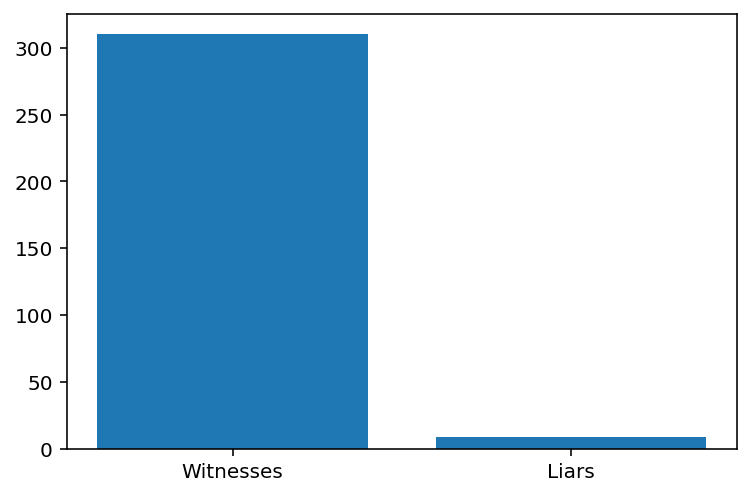

The ratio of witnesses to liars was: 34 to 1 (or 310 : 9).


In [75]:
%config InlineBackend.figure_format = 'retina'

d5 = {"Witnesses": 0, "Liars": 0} # The dictionary d5 keeps track of how many times 
                                  # strong_a_pseudoprime_test(561, a) returns True or False; 
                                  # i.e. how many times we find a liar or a witness. 

for a in [i for i in range(2, 561) if math.gcd(561, i) == 1]:
# Iterate through all bases a less than 561 and relatively prime to 561.
    
    if strong_a_pseudoprime_test(561, a): # If strong_a_pseudoprime_test(561, a) returns True, 
                                          # then we found a liar. 
        d5["Liars"] += 1
    else:                                 # Otherwise, we found a witness. 
        d5["Witnesses"] += 1
        
num_witnesses = d5["Witnesses"] # Store number of witnesses and liars in local variables. 
num_liars = d5["Liars"]
ratio = d5["Witnesses"] // d5["Liars"] # How many witnesses are there for every liar? 
        
plt.bar(d5.keys(), d5.values())  
plt.show()

print("The ratio of witnesses to liars was: {0} to 1 (or {1} : {2}).".format(ratio, num_witnesses, num_liars))

We can examine even a greater prevalence of witnesses for the Carmichael number $41041$. 

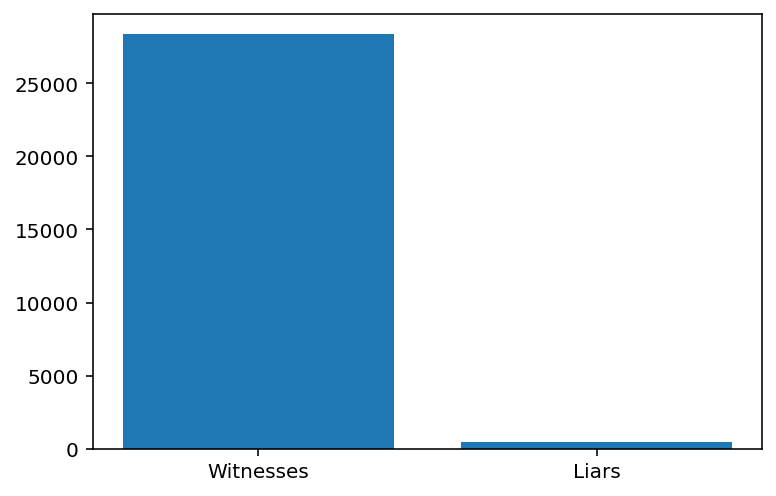

The ratio of witnesses to liars was: 63 to 1 (or 28350 : 449).


In [76]:
%config InlineBackend.figure_format = 'retina'

d6 = {"Witnesses": 0, "Liars": 0} # The dictionary d6 keeps track of how many times 
                                  # strong_a_pseudoprime_test(41041, a) returns True or False; 
                                  # i.e. how many times we find a liar or a witness. 

for a in [i for i in range(2, 41041) if math.gcd(41041, i) == 1]:
# Iterate through all bases a less than 41041 and relatively prime to 41041.
    
    if strong_a_pseudoprime_test(41041, a): # If strong_a_pseudoprime_test(41041, a) returns True 
                                            # then we found a liar. 
        d6["Liars"] += 1
    else:                                 # Otherwise, we found a witness. 
        d6["Witnesses"] += 1
        
num_witnesses = d6["Witnesses"] # Store number of witnesses and liars in local variables. 
num_liars = d6["Liars"]
ratio = d6["Witnesses"] // d6["Liars"] # How many witnesses are there for every liar? 
        
plt.bar(d6.keys(), d6.values())  
plt.show()

print("The ratio of witnesses to liars was: {0} to 1 (or {1} : {2}).".format(ratio, num_witnesses, num_liars))

Under `strong_a_pseudoprime_test(n, a)`, it is generally true that any composite number has more witnesses than liars. Given this fact, we can consider narrowing our choice of test bases so as to sufficiently conclude that $n$ is composite. 

Note that the composite numbers $n$ for which `strong_a_pseudoprime_test(n, a)` will return `True` are exactly those that satisfy the definition of a strong $a$-pseudoprime. The following table gives a list of the smallest strong pseudoprimes to a single prime base or multiple prime bases (Jaeschke, 1993). 

| Base(s)                                        	| Smallest Strong Pseudoprime   	|
|:--------------------------------------------------|:----------------------------------|
| 2                                              	| 2047                          	|
| 2, 3                                           	| 1373653                       	|
| 2, 3, 5                                        	| 25326001                      	|
| 2, 3, 5, 7                                     	| 3215031751                    	|
| 2, 3, 5, 7, 11                                 	| 2152302898747                 	|
| 2, 3, 5, 7, 11, 13                             	| 3474749660383                 	|
| 2, 3, 5, 7, 11, 13, 17                         	| 341550071728321               	|
| 2, 3, 5, 7, 11, 13, 17, 19, 23                 	| 3825123056546413051       	    |
| 2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37        | 318665857834031151167461          |


From the table, we say $2047$ is the smallest strong $2$-pseudoprime and $1373653$ is the smallest strong pseudoprime to the bases $2$ and $3$. That is, $1373653$ is the smallest composite integer to which we say is both a strong $2$-pseudoprime and a strong $3$-pseudoprime. Consequently, if an arbitrary integer $n$, where $2047 \leq n < 1373653$, causes both `strong_a_pseudoprime_test(n, 2)` and `strong_a_pseudoprime_test(n, 3)` to return `True`, then $n$ must be prime (without a doubt) because while it is true that any prime $n$ always causes `strong_a_pseudoprime_test(n, 2)` and `strong_a_pseudoprime_test(n 3)` to return `True` (see paragraph preceding **Remark 3**), the first composite integer to satisfy such conditions is $1373653 > n$. On the other hand, if such an $n$ caused either `strong_a_pseudoprime_test(n, 2)` or `strong_a_pseudoprime_test(n, 3)` to return `False`, then $n$ must be composite because for $n$ to be prime both `strong_a_pseudoprime_test(n, 2)` and `strong_a_pseudoprime_test(n, 3)` must return `True`, which is not the case. Here, we say that $2$ and $3$ *witness* the compositeness of $n$. 

## $4.4:$ Deterministic and probabilistic testing

Implementing the definition of strong $a$-pseudoprimes for a primality test is attributed to the work of computer scientist Gary Miller in 1976. Given that $n$ is less than some smallest strong pseudoprime to multiple base(s), we can unquestionably state the primality or compositeness of $n$. When we wish to test for an $n$ larger than $3.19 \times 10^{23} > 2^{64}$, we revert to a probabilistic version of Miller's test, provided by Michael Rabin. 

In [77]:
def Miller_Rabin(n):
    '''User enters an integer n, return False if n is composite. If return is True and n is less than 3.19E23, 
       then n is prime. If return is True and n is greater than or equal to 3.19E23, then n is probably prime.'''
    
    if n == 2: # return True for the only even prime number. 
        return True
    
    if n % 2 == 0: # return False if n is even. 
        return False
    
    # Following code was inspired by Marty Weissman's Python notebook on modular arithmetic and primality testing. 
    # A deterministic primality test is one in which does not involve randomization. 
    diagnosis = strong_a_pseudoprime_test(n, 2)  
    if n < 2047: # Note the initial value of diagnosis; test base a = 2. 
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 3) 
    if 2047 <= n < 1373653: # Note the updated value of diagnosis; test bases a = 2, 3.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 5)
    if 1373653 <= n < 25326001: # Test bases a = 2, 3, 5.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 7) 
    if 25326001 <= n < 3215031751: # Test bases a = 2, 3, 5, 7.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 11)  
    if 3215031751 <= n < 2152302898747: # Test bases a = 2, 3, 5, 7, 11.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 13)  
    if 2152302898747 <= n < 3474749660383: # Test bases a = 2, 3, 5, 7, 11, 13.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 17)  
    if 3474749660383 <= n < 341550071728321: # Test bases a = 2, 3, 5, 7, 11, 13, 17.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 19) and strong_a_pseudoprime_test(n, 23) 
    if 341550071728321 <= n < 3825123056546413051: # Test bases a = 2, 3, 5, 7, 11, 13, 17, 19, 23.
        return diagnosis
    diagnosis = diagnosis and strong_a_pseudoprime_test(n, 29) and strong_a_pseudoprime_test(n, 31) \
    and strong_a_pseudoprime_test(n, 37)
    if 3825123056546413051 <= n < 318665857834031151167461: # Test bases a = 2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37.
        return diagnosis
    
    if n >= 318665857834031151167461: # We revert to a probabilistic test, involving 50 randomly chosen bases a. 

        trial_num = 0 # Keep track of number of trials. 
    
        while trial_num != 50: # We are done testing when we have completed 50 trials. 
            
            a = random.randint(2, n) # Choose a random base a in the range 2, 3, ... , n - 1. 
            
            if math.gcd(n, a) == 1: # In order to find a witness, we require that our test base a is
                                    # relatively prime to n. 
                    
                if strong_a_pseudoprime_test(n, a) == False: # Check if a is a witness. 
                    
                    return False # return False if we found a witness; i.e. n is composite. 
                
                trial_num += 1 # Conduct the next trial. 
                
            else: # If we find that our test base a is not relatively prime to n then we restart the current
                  # iteration of the while-loop. 
                continue 
        
        return True # return True if we did not find any witnesses from 50 trials; i.e. n is probably prime. 

In [78]:
Miller_Rabin(331)

True

Recall that $n = 331$ was diagnosed as a probable prime by `trial_a_pseudoprime(n)`, but with `Miller_Rabin(331)` we can say that $n = 331$ is in fact a prime (actually called a Happy prime). 

In [79]:
Miller_Rabin(181081) # n = 181081 is a Dihedral prime. 

True

In [80]:
Miller_Rabin(41041) # n = 41041 is a Carmichael number. 

False

`Miller_Rabin(n)` returns correctly for primes $331$ and $181081$, and Carmichael number $41041$. We next observe a time comparison between `Miller_Rabin(n)`, `trial_division(n)`, and `trial_a_pseudoprime(n)`. 

In [81]:
trial_division(41041)

False

In [82]:
trial_a_pseudoprime(41041) # From trial_a_pseudoprime(n), True means probably prime. 

True

In [83]:
mr_time1 = timeit.timeit("Miller_Rabin(41041)", "from __main__ import Miller_Rabin", number = 10000)
td_time1 = timeit.timeit("trial_division(41041)", "from __main__ import trial_division", number = 10000)
tp_time1 = timeit.timeit("trial_a_pseudoprime(41041)", "from __main__ import trial_a_pseudoprime", number = 10000)

print("Miller_Rabin(41041) took {:.4f} seconds.".format(mr_time1))
print("trial_division(41041) took {:.4f} seconds.".format(td_time1))
print("trial_a_pseudoprime(41041) took {:.4f} seconds.".format(tp_time1))

Miller_Rabin(41041) took 0.0612 seconds.
trial_division(41041) took 0.0074 seconds.
trial_a_pseudoprime(41041) took 1.4974 seconds.


In [84]:
trial_division(181081)

True

In [85]:
trial_a_pseudoprime(181081)

True

In [86]:
mr_time2 = timeit.timeit("Miller_Rabin(181081)", "from __main__ import Miller_Rabin", number = 10000)
td_time2 = timeit.timeit("trial_division(181081)", "from __main__ import trial_division", number = 10000)
tp_time2 = timeit.timeit("trial_a_pseudoprime(181081)", "from __main__ import trial_a_pseudoprime", number = 10000)

print("Miller_Rabin(181081) took {:.4f} seconds.".format(mr_time2))
print("trial_division(181081) took {:.4f} seconds.".format(td_time2))
print("trial_a_pseudoprime(181081) took {:.4f} seconds.".format(tp_time2))

Miller_Rabin(181081) took 0.1341 seconds.
trial_division(181081) took 0.1887 seconds.
trial_a_pseudoprime(181081) took 1.5567 seconds.


Though not the fastest to detect the compositeness of $41041$, `Miller_Rabin(n)` should have been the fastest of the three to detect the primality of $181081$. Below we test `Miller_Rabin(n)` with higher digit primes, fixing `number` at 100 iterations. 

In [87]:
Miller_Rabin(1111111111111111111) # n is a 19-digit prime. 

True

In [88]:
Miller_Rabin(618970019642690137449562111) # n is a Mersenne prime. 

True

In [89]:
Miller_Rabin(1000000000000066600000000000001) # n is Belphegor's prime. 

True

In [90]:
mr_time3 = timeit.timeit("Miller_Rabin(1111111111111111111)", "from __main__ import Miller_Rabin", number = 100)
mr_time4 = timeit.timeit("Miller_Rabin(618970019642690137449562111)", "from __main__ import Miller_Rabin", number = 100)
mr_time5 = timeit.timeit("Miller_Rabin(1000000000000066600000000000001)", "from __main__ import Miller_Rabin", number = 100)

print("Miller_Rabin(1111111111111111111) took {:.4f} seconds.".format(mr_time3))
print("Miller_Rabin(618970019642690137449562111) took {:.4f} seconds.".format(mr_time4))
print("Miller_Rabin(1000000000000066600000000000001) took {:.4f} seconds.".format(mr_time5))

Miller_Rabin(1111111111111111111) took 0.0239 seconds.
Miller_Rabin(618970019642690137449562111) took 0.3379 seconds.
Miller_Rabin(1000000000000066600000000000001) took 2.2059 seconds.


In [ ]:
trial_division(1000000000000066600000000000001) # Reader may omit execution of this cell - it could take a while. 

`trial_division(n)` will take very long to return `True` for Belphegor's prime, and while `trial_a_pseudoprime(n)` will be faster in doing this, `trial_a_pseudoprime(n)` is generally slow in detecting primality or compositeness for any $n$ and always misdiagnoses probable primality for Carmichael numbers. `Miller_Rabin(n)`, on the other hand, efficiently detects primality or compositeness of $n$, including Carmichael numbers. We address the question of reliability of `Miller_Rabin(n)` with the following Theorem (Childs, 1995). 

**Theorem 3 (Rabin's Theorem)**. Let $n$ be an odd composite number. Then at most $\frac{1}{4}$ of the bases $a$ are liars for $n$. 

The statement of Rabin's Theorem can be understood in terms of conditional probability: Let $X$ be the event that $n$ is composite. For $i = 1, 2, \ldots, 50$, let $gcd(n, a_{i}) =1$ where $1 < a_{i} < n$, and let $A_{i}$ be the event that $a_{i}$ is a liar. Then, Rabin's Theorem states that 

$$
\begin{align*}
Pr(A_{1} | X) &\leq \frac{1}{4} \\ 
Pr(A_{2} | X) &\leq \frac{1}{4} \\ 
\vdots \\ 
Pr(A_{50} | X) &\leq \frac{1}{4} \\
\Rightarrow Pr(A_{1} \cap A_{2} \cap \ldots \cap A_{50} | X) &\leq \big(\frac{1}{4}\big)^{50} \\
\end{align*} 
$$

where $A_{1} \cap A_{2} \cap \ldots \cap A_{50} = Y_{50}$ is the event that $n$ is probably prime. Note that the probability of the complement of the above conditional event is given by $Pr(Y_{50}^\mathrm{C} | X) = 1 - Pr(Y_{50} | X)$, which is the probability of the event that at least one of $a_{i}$ is a witness to the compositeness of $n$. Then, observe that 

$$
\begin{align*}
Pr(Y_{50} | X) &\leq \big(\frac{1}{4}\big)^{50} \\
\Rightarrow -1 + Pr(Y_{50} | X) &\leq -1 + 4^{-50} \\
\Rightarrow -\big(1 - Pr(Y_{50} | X)\big) &\leq -(1 - 4^{-50}) \\ 
\Rightarrow 1 - Pr(Y_{50} | X) &\geq 1 - 4^{-50} \\
\Rightarrow Pr(Y_{50}^\mathrm{C} | X) &\geq 1 - 4^{-50} \approx 1 - 7.89 \times 10^{-31} \\
\end{align*}
$$

which is nearly 100%. In other words, we can trust that any composite $n$ will be witnessed by at least one base $a$ among $50$ test bases. We can also say that, in the event that $n$ is probably prime, there is a very small probability that `Miller_Rabin(n)` is wrong about such a diagnosis (in the worst case, $Pr(Y_{50} | X) = 4^{-50} \approx 7.89 \times 10^{31}$). Hence, we can reasonably trust the probably prime diagnosis from `Miller_Rabin(n)`. 

For a practical application, we return to the interests of the RSA Cryptosystem and the need to verify the primality of very large primes. Traditionally, as a preventative measure against cyber threats, RSA offers factor challenge problems to the public, awarding cash prizes to anyone who can factor large composite numbers into exactly two prime factors. Called the RSA numbers, the first number presented to the public was RSA-$129$. Composed of exactly $129$-digits, RSA-$129$ was claimed by the founders of RSA to take the fastest computers of 1977 running for millions of times the age of the universe to find its two prime factors (Gardner, 1977). In 1994, a team led by Derek Atkins and Arjen Lenstra found the two prime factors of RSA-$129$, which was said to take several months and the efforts of 600 programmers and mathematicians. The team was awarded a whopping prize of $100 (Clawson, 1996). 

Using `Miller_Rabin(n)`, we can verify the compositeness of RSA-$129$ and the primality of its prime factors in a timely manner. 

In [91]:
# n is RSA-129, a large composite number. 

Miller_Rabin(114381625757888867669235779976146612010218296721242362562561842935706935245733897830597123563958705058989075147599290026879543541)

False

In [92]:
# n is one of the prime factors of RSA-129, discovered by Atkins and Lenstra in 1994. 

Miller_Rabin(3490529510847650949147849619903898133417764638493387843990820577)

True

In [93]:
# n is the other prime factor of RSA-129, discovered by Atkins and Lenstra in 1994. 

Miller_Rabin(32769132993266709549961988190834461413177642967992942539798288533)

True

In [94]:
# Time Miller_Rabin(n) for RSA-129 and its two prime factors. Note that number = 100. 

time_RSA129 = timeit.timeit("Miller_Rabin(114381625757888867669235779976146612010218296721242362562561842935706935245733897830597123563958705058989075147599290026879543541)", "from __main__ import Miller_Rabin", number = 100)
time_RSA129_prime1 = timeit.timeit("Miller_Rabin(3490529510847650949147849619903898133417764638493387843990820577)", "from __main__ import Miller_Rabin", number = 100)
time_RSA129_prime2 = timeit.timeit("Miller_Rabin(32769132993266709549961988190834461413177642967992942539798288533)", "from __main__ import Miller_Rabin", number = 100)

print("Miller_Rabin(n) detected compositeness of RSA-129 in {:.4f} seconds.".format(time_RSA129))
print("Miller_Rabin(n) detected primality of first prime factor of RSA-129 in {:.4f} seconds.".format(time_RSA129_prime1))
print("Miller_Rabin(n) detected primality of second prime factor of RSA-129 in {:.4f} seconds.".format(time_RSA129_prime2))

Miller_Rabin(n) detected compositeness of RSA-129 in 0.2382 seconds.
Miller_Rabin(n) detected primality of first prime factor of RSA-129 in 4.0921 seconds.
Miller_Rabin(n) detected primality of second prime factor of RSA-129 in 1.8443 seconds.


In [95]:
# Other RSA numbers. Reader may omit execution of the following cells. 

# n is RSA-220.

Miller_Rabin(2260138526203405784941654048610197513508038915719776718321197768109445641817966676608593121306582577250631562886676970448070001811149711863002112487928199487482066070131066586646083327982803560379205391980139946496955261)

False

In [96]:
# n is one of the prime factors of RSA-220 (Bai, Gaudry, Kruppa, Thomè & Zimmermann, 2016). 

Miller_Rabin(68636564122675662743823714992884378001308422399791648446212449933215410614414642667938213644208420192054999687)

True

In [97]:
# n is the other prime factor of RSA-220. (Bai, Gaudry, Kruppa, Thomè & Zimmermann, 2016). 

Miller_Rabin(32929074394863498120493015492129352919164551965362339524626860511692903493094652463337824866390738191765712603)

True

In [98]:
# Time Miller_Rabin(n) for RSA-220 and its two prime factors. 

time_RSA220 = timeit.timeit("Miller_Rabin(2260138526203405784941654048610197513508038915719776718321197768109445641817966676608593121306582577250631562886676970448070001811149711863002112487928199487482066070131066586646083327982803560379205391980139946496955261)", "from __main__ import Miller_Rabin", number = 100)
time_RSA220_prime1 = timeit.timeit("Miller_Rabin(68636564122675662743823714992884378001308422399791648446212449933215410614414642667938213644208420192054999687)", "from __main__ import Miller_Rabin", number = 100)
time_RSA220_prime2 = timeit.timeit("Miller_Rabin(32929074394863498120493015492129352919164551965362339524626860511692903493094652463337824866390738191765712603)", "from __main__ import Miller_Rabin", number = 100)

print("Miller_Rabin(n) detected compositeness of RSA-220 in {:.4f} seconds.".format(time_RSA220))
print("Miller_Rabin(n) detected primality of first prime factor of RSA-220 in {:.4f} seconds.".format(time_RSA220_prime1))
print("Miller_Rabin(n) detected primality of second prime factor of RSA-220 in {:.4f} seconds.".format(time_RSA220_prime2))

Miller_Rabin(n) detected compositeness of RSA-220 in 0.8123 seconds.
Miller_Rabin(n) detected primality of first prime factor of RSA-220 in 3.5496 seconds.
Miller_Rabin(n) detected primality of second prime factor of RSA-220 in 3.7017 seconds.


In [99]:
# n is RSA-180.

Miller_Rabin(191147927718986609689229466631454649812986246276667354864188503638807260703436799058776201365135161278134258296128109200046702912984568752800330221777752773957404540495707851421041)

False

In [100]:
# n is one of the prime factors of RSA-180 (Danilov & Popovyan, 2010).

Miller_Rabin(400780082329750877952581339104100572526829317815807176564882178998497572771950624613470377)

True

In [101]:
# n is the second prime factor of RSA-180 (Danilov & Popovyan, 2010).

Miller_Rabin(476939688738611836995535477357070857939902076027788232031989775824606225595773435668861833)

True

In [102]:
# Time Miller_Rabin(n) for RSA-180 and its two prime factors. 

time_RSA180 = timeit.timeit("Miller_Rabin(191147927718986609689229466631454649812986246276667354864188503638807260703436799058776201365135161278134258296128109200046702912984568752800330221777752773957404540495707851421041)", "from __main__ import Miller_Rabin", number = 100)
time_RSA180_prime1 = timeit.timeit("Miller_Rabin(400780082329750877952581339104100572526829317815807176564882178998497572771950624613470377)", "from __main__ import Miller_Rabin", number = 100)
time_RSA180_prime2 = timeit.timeit("Miller_Rabin(476939688738611836995535477357070857939902076027788232031989775824606225595773435668861833)", "from __main__ import Miller_Rabin", number = 100)

print("Miller_Rabin(n) detected compositeness of RSA-180 in {:.4f} seconds.".format(time_RSA180))
print("Miller_Rabin(n) detected primality of first prime factor of RSA-180 in {:.4f} seconds.".format(time_RSA180_prime1))
print("Miller_Rabin(n) detected primality of second prime factor of RSA-180 in {:.4f} seconds.".format(time_RSA180_prime2))

Miller_Rabin(n) detected compositeness of RSA-180 in 0.7640 seconds.
Miller_Rabin(n) detected primality of first prime factor of RSA-180 in 4.4039 seconds.
Miller_Rabin(n) detected primality of second prime factor of RSA-180 in 3.9222 seconds.


# Conclusion

Now able to detect the primality of numbers with $110$-digits or more, we can consider the implementation of `Miller_Rabin(n)` in generating long lists of primes, also known as prime sieves. `Miller_Rabin(n)` may also be used in a search for large primes that meet some special characteristic, such as Gaussian primes of the form $4m + 3$ or Mersenne primes satisfying $2^{m} - 1$, for arbitrary $m$. By first constructing an efficient means to answer the question of whether $n > 2^{64}$ is prime or composite, empowering as it is to conclude primality for such large numbers, the next step is to consider the applied and theoretical uses for such an $n$. 

# References

Bai, S., Gaudry, P., Kruppa, A., Thomè, E., & Zimmermann, P. (2016). Factorisation of RSA-220 with CADO-NFS [Online]. Available: https://lists.gforge.inria.fr/pipermail/cado-nfs-discuss/2016-May/000626.html. 

Childs, L. N. (1995). *A Concrete Introduction to Higher Algebra* (Second). Albany, NY: Springer.

Clawson, C. C. (1996). *Mathematical Mysteries, The Beauty and Magic of Numbers*, 184-200. Boston, MA: Springer. 

Danilov, S. A. & Popovyan, I. A. (2010). Factorization of RSA-180 [Online]. Available: https://eprint.iacr.org/2010/270. 

Gardner, M. (1977, August). A new kind of cipher that would take millions of years to break. *Scientific American*, 120–124. 

Jaeschke, G. (1993). On Strong Pseudoprimes to Several Bases. *Mathematics of Computation*, *61*(204), 915–926. 

Pomerance, C., Selfridge, J. L., & Wagstaff, S. S. (1980). The Pseudoprimes to $25 \cdot 10^{9}$. *Mathematics of Computation*, *35*(151), 1003–1026. 

Ribenboim, P. (1996). *The New Book of Prime Number Records*. New York, NY: Springer. 

Weissman, M. H. (2017). *An Illustrated Theory of Numbers*. American Mathematical Society. 